In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

KeyboardInterrupt: 

In [2]:
import cv2
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os

2026-03-28 11:08:35.357239: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774696115.553961      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774696115.615120      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774696116.138768      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774696116.138804      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774696116.138807      55 computation_placer.cc:177] computation placer alr

In [3]:
path_infected = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Parasitized"
path_uninfected = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Uninfected"

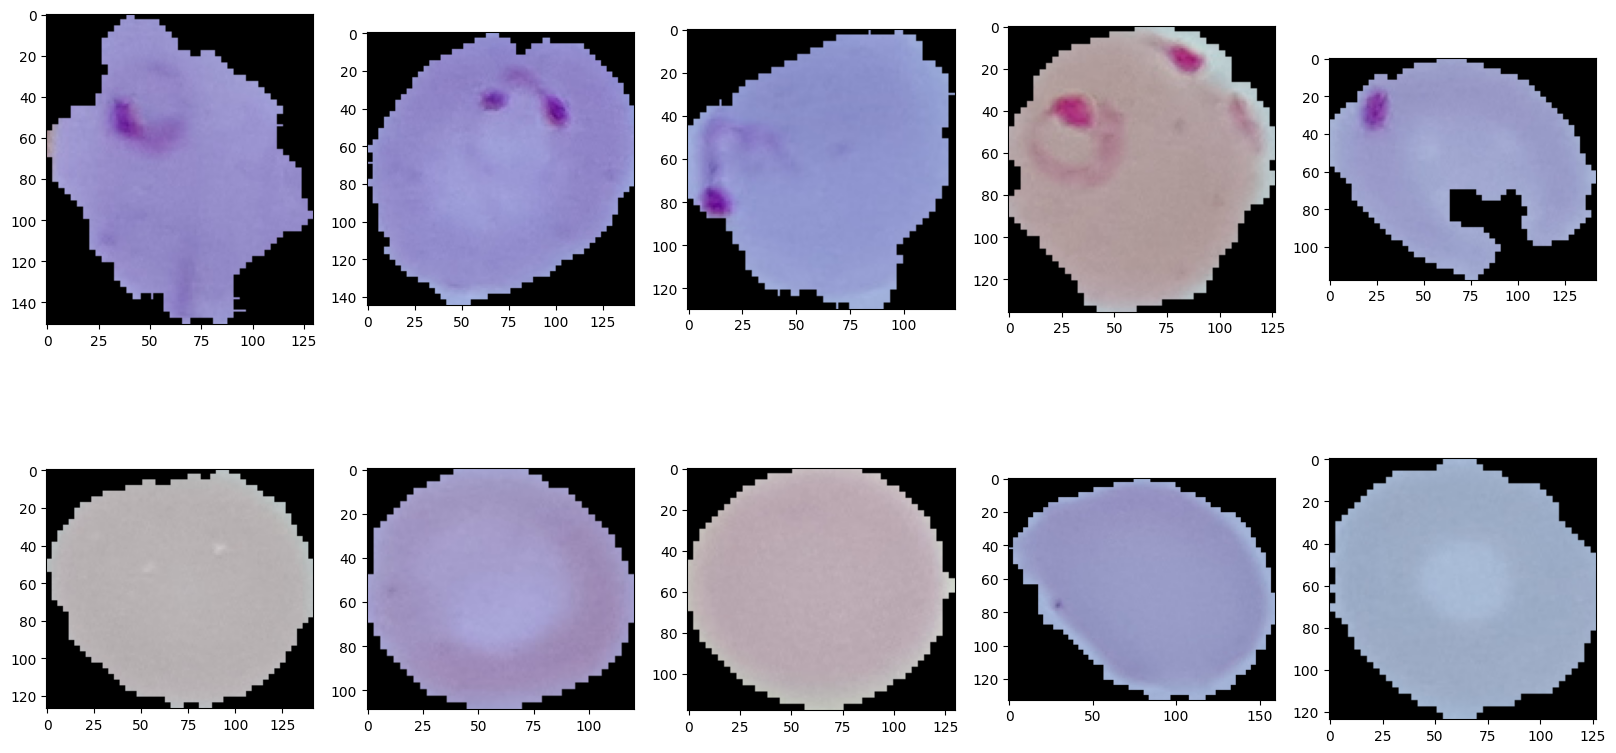

In [4]:
plt.figure(figsize=(20,10))
for i in range(0,10):
    plt.subplot(2,5,1 + i)
    if i < 5:
        img = cv2.imread(os.path.join(path_infected,os.listdir(path_infected)[i]))
    else:
        img = cv2.imread(os.path.join(path_uninfected,os.listdir(path_uninfected)[i]))
    plt.imshow(img)

In [5]:
img1 = cv2.imread(os.path.join(path_infected,os.listdir(path_infected)[0]))
img2 = cv2.imread(os.path.join(path_infected,os.listdir(path_infected)[1]))
print(img1.shape)
print(img2.shape)

(151, 130, 3)
(145, 142, 3)


Image sizes are different

In [6]:
def get_label(path):

    splitted_path = tf.strings.split(path,os.path.sep)

    label = splitted_path[-2]

    return tf.cast(label == "Parasitized",dtype='int64')

def process_path(path):
    label = get_label(path)

    file_raw = tf.io.read_file(path)
    file_tensor = tf.io.decode_png(file_raw,channels=3)
    file_tensor = tf.image.resize(file_tensor,[120,120])
    file_tensor = file_tensor/255

    return file_tensor, label

In [87]:
#buidling input pipeline for data loading and preprocessing
tf.random.set_seed(42)
labels = [i for i in [path_infected.split("/")[-1],path_uninfected.split('/')[-1]]]

list_ds= tf.data.Dataset.list_files("/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/*/*.png",shuffle=False)

list_ds = list_ds.shuffle(
    buffer_size=len(list_ds), 
    seed=42, 
    reshuffle_each_iteration=False
)

count = len(list_ds)

train_ds = list_ds.take(int(count * 0.7))
val_ds = list_ds.skip(int(count * 0.7)).take(int(count * 0.1))
test_ds = list_ds.skip(int(count * 0.8))

train_ds = train_ds.map(process_path).shuffle(1000).batch(64).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(process_path).batch(64).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(process_path).batch(64).prefetch(tf.data.AUTOTUNE)



In [88]:
# Check the total number of batches across all three
total_batches = len(train_ds) + len(val_ds) + len(test_ds)
print(f"Total Batches: {total_batches}") 
# Should be around 431 (27,558 / 64)


Total Batches: 433


In [89]:
model = tf.keras.applications.MobileNetV2(
    input_shape=(120,120,3),
    weights='imagenet',
    include_top = False
)

/tmp/ipykernel_55/3315679844.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = tf.keras.applications.MobileNetV2(


In [90]:
model.trainanble = False

In [91]:
from keras import Model
from keras.layers import Dense,GlobalMaxPooling2D

In [92]:
flatten = GlobalMaxPooling2D()(model.output)

x = Dense(64,activation="relu")(flatten)

y = Dense(1,activation="sigmoid")(x)

main_model = Model(inputs = [model.input],outputs=[y])

In [93]:
from keras.callbacks import EarlyStopping

early = EarlyStopping(
    min_delta=  0.001,
    monitor = "val_accuracy",
    patience = 10,
    verbose=1,
    restore_best_weights=True
)

In [94]:
main_model.compile(loss="binary_crossentropy", optimizer="adam",metrics=["accuracy","auc"])

In [95]:
main_model.fit(train_ds,validation_data=(val_ds),epochs=300,callbacks= early)

Epoch 1/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 93s 164ms/step - accuracy: 0.9213 - auc: 0.9597 - loss: 0.2940 - val_accuracy: 0.8544 - val_auc: 0.9134 - val_loss: 0.9151
Epoch 2/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.9645 - auc: 0.9916 - loss: 0.1040 - val_accuracy: 0.9024 - val_auc: 0.9261 - val_loss: 0.7214
Epoch 3/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.9677 - auc: 0.9937 - loss: 0.0937 - val_accuracy: 0.9274 - val_auc: 0.9452 - val_loss: 0.5361
Epoch 4/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.9696 - auc: 0.9949 - loss: 0.0833 - val_accuracy: 0.6951 - val_auc: 0.8250 - val_loss: 1.8173
Epoch 5/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.9707 - auc: 0.9957 - loss: 0.0796 - val_accuracy: 0.7920 - val_auc: 0.9693 - val_loss: 0.5932
Epoch 6/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - accuracy: 0.9751 - auc: 0.9953 - loss: 0.0755 - val_accuracy: 0.8882 - val_auc: 0.9207 - val_loss: 0.7873
Epoch 7/300
302/302 ━

In [96]:
pred = main_model.evaluate(test_ds)

87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.9511 - auc: 0.9739 - loss: 0.1637


In [97]:
pred_prob = main_model.predict(test_ds)

87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step


In [98]:
pred_prob.reshape(5512)

import numpy as np

all_labels = []

for x, y in test_ds:
    all_labels.append(y.numpy())

y_true = np.concatenate(all_labels, axis=0)

print(f"Total labels extracted: {len(y_true)}")


Total labels extracted: 5512


<Figure size 800x600 with 0 Axes>

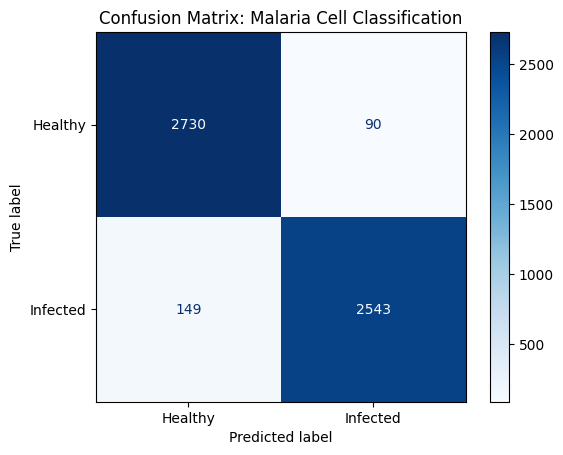

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, (pred_prob > 0.5).astype(int))

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Infected'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix: Malaria Cell Classification')
plt.show()


In [100]:
main_model.save("model.keras")

In [ ]:
main_model.export("model_tf")
